In [2]:
import torch, sys, platform                                                                         # +-- WHICH GPU DID COLAB HAND OUT -------------------------------
print("Python  :", sys.version.split()[0])                                                          # | Everything later depends on this answer. get_device_capability
print("PyTorch :", torch.__version__)                                                               # | returns the card's compute capability; 7.5 is a T4. That
print("CUDA?   :", torch.cuda.is_available())                                                       # | number decides the numeric format used for the fast runs: bf16
if torch.cuda.is_available():                                                                       # | keeps fp32's exponent range but the T4's tensor cores do not
    print("GPU     :", torch.cuda.get_device_name(0))                                               # | implement it, so Phase B uses fp16 and has to add loss scaling
    cc = torch.cuda.get_device_capability(0)                                                        # | to stop small gradients rounding to zero. device is chosen
    print("Compute :", cc)                                                                          # | once here and every tensor in the notebook is built on it.
    # T4 is compute 7.5 -> no fast bf16; we'll use fp16 when we go for speed.
    print("Note    : T4 -> use fp16 (not bf16) for the fast stuff later.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device  :", device)

Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA?   : True
GPU     : Tesla T4
Compute : (7, 5)
Note    : T4 -> use fp16 (not bf16) for the fast stuff later.
device  : cuda


# Step 1 — One neuron, by hand

A neuron is just: $\hat y = w x + b$. That's it. A weight, an input, a bias.

To *learn* means: find $w, b$ that make $\hat y$ match real data $y$. We measure "wrongness" with a **loss** — mean squared error:

$$L = \frac{1}{N}\sum (\hat y - y)^2$$

Learning = roll $L$ downhill. To know which way is downhill, we use calculus — the **gradient** (slope of $L$ w.r.t. each knob):

$$\frac{\partial L}{\partial w} = \frac{1}{N}\sum 2(\hat y - y)\,x \qquad \frac{\partial L}{\partial b} = \frac{1}{N}\sum 2(\hat y - y)$$

Then nudge each knob *against* its gradient: `w -= lr * dL/dw`. Repeat. That loop **is** machine learning. Below we write it out — no autograd, no `nn`. We hide the true answer ($w=2, b=-1$) in the data and watch the neuron discover it.

In [3]:
# --- One neuron, fully by hand. No autograd. ---                                                   # +-- ONE NEURON, TWO KNOBS, A HIDDEN RULE -----------------------
torch.manual_seed(0)                                                                                # | The data comes from a rule the neuron is never told: y = 2x -
                                                                                                    # | 1, plus noise so that no line can pass through every point. w
# Fake reality: y = 2x - 1 (the neuron does NOT know this; it must discover it)                     # | and b start at zero, which is deliberately wrong, so the run
N = 200                                                                                             # | has something to show. lr is how far each step travels
x = torch.linspace(-3, 3, N)                                                                        # | downhill: too small and 200 steps never arrive, too large and
y_true = 2.0 * x - 1.0 + 0.1 * torch.randn(N)   # a little noise, like real data                    # | the update jumps past the bottom and the loss climbs. The
                                                                                                    # | three history lists exist only for the plot afterwards;
# The neuron's two knobs, started at "wrong" guesses                                                # | training never reads them.
w = torch.tensor(0.0)
b = torch.tensor(0.0)
lr = 0.05                                        # learning rate = step size downhill

# History, so we can SEE the descent afterward
w_hist, b_hist, loss_hist = [], [], []

for step in range(201):                                                                             # +-- THE FOUR STEPS THAT ARE ALL OF LEARNING --------------------
    # 1) FORWARD: what the neuron predicts right now                                                # | Predict, measure the error, work out how the error changes
    y_hat = w * x + b                                                                               # | when each knob moves, move each knob against that change.
                                                                                                    # | Squaring the error makes one badly-missed point count for more
    # 2) LOSS: how wrong it is (mean squared error)                                                 # | than several near-misses. The two gradient lines are the chain
    err   = y_hat - y_true                                                                          # | rule for this exact loss, done on paper: d/dw of (wx+b-y)^2 is
    loss  = (err ** 2).mean()                                                                       # | 2(wx+b-y)x and d/db is 2(wx+b-y), and the mean matches the
                                                                                                    # | mean taken in the loss. History is recorded before the update
    # 3) GRADIENTS: slope of loss w.r.t each knob (chain rule, done by hand)                        # | so each saved w,b is the pair that actually produced the saved
    dL_dw = (2 * err * x).mean()                                                                    # | loss. The gradient points uphill, so subtracting it goes down.
    dL_db = (2 * err).mean()

    # record BEFORE the step (this knob position produced this loss)
    w_hist.append(w.item()); b_hist.append(b.item()); loss_hist.append(loss.item())

    # 4) UPDATE: step each knob downhill
    w -= lr * dL_dw
    b -= lr * dL_db

    if step % 40 == 0:
        print(f"step {step:3d} | loss {loss:.4f} | w {w:.3f} (target 2.000) | b {b:.3f} (target -1.000)")

print("\nLearned:  w =", round(w.item(), 3), " b =", round(b.item(), 3))
print("The neuron discovered the hidden rule from data alone.")

step   0 | loss 13.0697 | w 0.604 (target 2.000) | b -0.100 (target -1.000)
step  40 | loss 0.0094 | w 1.995 (target 2.000) | b -0.989 (target -1.000)
step  80 | loss 0.0092 | w 1.995 (target 2.000) | b -1.002 (target -1.000)
step 120 | loss 0.0092 | w 1.995 (target 2.000) | b -1.002 (target -1.000)
step 160 | loss 0.0092 | w 1.995 (target 2.000) | b -1.002 (target -1.000)
step 200 | loss 0.0092 | w 1.995 (target 2.000) | b -1.002 (target -1.000)

Learned:  w = 1.995  b = -1.002
The neuron discovered the hidden rule from data alone.


In [5]:
# --- plotting helper: renders inline for you, stays small enough for the tool channel ---          # +-- KEEP THE INLINE IMAGE SMALL --------------------------------
import os, matplotlib.pyplot as plt                                                                 # | Colab returns every rendered figure through the tool channel,
os.makedirs("/content/plots", exist_ok=True)                                                        # | and a full-resolution PNG is large enough to crowd out the
                                                                                                    # | rest of the output. figure.dpi affects only the inline copy,
def show(fig, name, dpi_inline=62):                                                                 # | so lowering it shrinks what comes back, while savefig writes a
    """Keep figure.dpi low so the INLINE png is small; save a crisp copy to disk."""                # | crisp 120-dpi file to disk. Every plot in the notebook goes
    fig.set_dpi(dpi_inline)                                   # controls inline size                # | through this one function.
    fig.savefig(f"/content/plots/{name}.png", dpi=120, bbox_inches="tight")  # crisp copy
    plt.show()
    print(f"(also saved -> /content/plots/{name}.png)")
print("show() ready")

show() ready


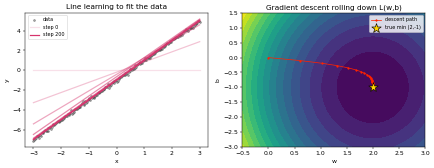

(also saved -> /content/plots/neuron_descent.png)


In [7]:
import numpy as np                                                                                  # +-- REPLAYING THE DESCENT AS LINES -----------------------------
                                                                                                    # | The recorded history is drawn as a series of lines over one
xn, yn = x.numpy(), y_true.numpy()                                                                  # | scatter of the data. snaps picks seven steps, bunched early
wh, bh, lh = np.array(w_hist), np.array(b_hist), np.array(loss_hist)                                # | where the line moves fast and thinning out later where it
                                                                                                    # | barely moves. alpha rises with the index so later lines are
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.0))                                             # | darker, and only the first and last get a legend entry so the
                                                                                                    # | legend stays to two rows.
# ---- LEFT: the line rotating into the data ----
axL.scatter(xn, yn, s=10, alpha=0.5, color="#444", label="data", zorder=1)
snaps = [0, 2, 5, 10, 20, 40, 200]
xs = np.array([xn.min(), xn.max()])
for i, s in enumerate(snaps):
    a = 0.15 + 0.85 * i / (len(snaps) - 1)
    axL.plot(xs, wh[s]*xs + bh[s], color="#d6336c", alpha=a, lw=2,
             label=f"step {s}" if s in (0, 200) else None, zorder=2)
axL.set_title("Line learning to fit the data")
axL.set_xlabel("x"); axL.set_ylabel("y"); axL.legend(loc="upper left", fontsize=8)

# ---- RIGHT: the loss surface, with the descent path ----                                          # +-- THE LOSS AS A LANDSCAPE OVER BOTH KNOBS --------------------
W, B = np.meshgrid(np.linspace(-0.5, 3.0, 120), np.linspace(-3.0, 1.5, 120))                        # | The right panel draws the loss itself as a function of w and
Yhat = W[..., None]*xn + B[..., None]                                                               # | b. W and B are a 120x120 grid of candidate knob settings;
L = ((Yhat - yn)**2).mean(axis=-1)                                                                  # | broadcasting them against the 200 data points gives every
cf = axR.contourf(W, B, L, levels=16, cmap="viridis")                                               # | prediction for every setting, and the mean over the last axis
axR.plot(wh, bh, "-o", color="#ff2200", ms=2.5, lw=1.2, label="descent path")                       # | collapses that to one loss per setting. The red path is the
axR.scatter([2.0], [-1.0], marker="*", s=260, color="gold",                                         # | recorded history and the star is the rule that made the data.
            edgecolor="k", zorder=5, label="true min (2,-1)")                                       # | The valley is elongated because the loss reacts faster to b
axR.set_title("Gradient descent rolling down L(w,b)")                                               # | than to w over this region.
axR.set_xlabel("w"); axR.set_ylabel("b"); axR.legend(loc="upper right", fontsize=8)

plt.tight_layout()
show(fig, "neuron_descent", dpi_inline=44)

## Step 2 — A network: hidden layer + backprop, by hand

One neuron = one straight line. To bend, we **stack**: send the input through a *hidden layer* of many neurons, squash each with a nonlinearity, then combine. Our net:

$$
\underbrace{z_1 = XW_1 + b_1}_{\text{(N,H)}}\;\to\;
a_1=\tanh(z_1)\;\to\;
\underbrace{z_2 = a_1W_2 + b_2}_{\text{(N,1)}}\;\to\;
p=\sigma(z_2)
$$

Loss = binary cross-entropy: $L = -\frac1N\sum\big[y\log p + (1-y)\log(1-p)\big]$.

**The whole game is getting $\partial L/\partial$(every weight).** We do it by hand with the chain rule, flowing *backward*:

| backward step | formula | shape |
|---|---|---|
| output error | $dz_2 = (p - y)/N$ | (N,1) |
| grad $W_2$ | $dW_2 = a_1^\top dz_2$ | (H,1) |
| grad into hidden | $da_1 = dz_2\,W_2^\top$ | (N,H) |
| through tanh | $dz_1 = da_1\,(1-a_1^2)$ | (N,H) |
| grad $W_1$ | $dW_1 = X^\top dz_1$ | (2,H) |

Each line is just "local slope × the gradient arriving from above." That **is** backpropagation — no autograd, no magic. Same downhill step as before, now for thousands of weights at once.

In [8]:
# --- A 2-layer MLP, fully by hand. Still NO autograd. ---                                          # +-- TWO CRESCENTS NO STRAIGHT LINE CAN SPLIT -------------------
from sklearn.datasets import make_moons                                                             # | make_moons gives two interleaved arcs, which is exactly the
                                                                                                    # | case a single neuron cannot solve: its boundary is one
torch.manual_seed(1)                                                                                # | straight line. The labels are reshaped into a column so they
Xnp, ynp = make_moons(n_samples=600, noise=0.20, random_state=0)                                    # | line up with the network's output shape. H is the hidden
X = torch.tensor(Xnp, dtype=torch.float32)            # (600, 2)                                    # | width, so 16 neurons each pick out one direction in the input
y = torch.tensor(ynp, dtype=torch.float32).view(-1, 1) # (600, 1)                                   # | plane and the second layer combines them. The weights must
                                                                                                    # | start random, because two neurons with identical weights would
H = 16                                                 # hidden neurons                             # | receive identical gradients forever and never split apart;
# weights: small random; biases: zero  (init matters — we'll revisit when scaling)                  # | biases can start at zero. The 0.5 scale is a guess, and Phase
W1 = torch.randn(2, H) * 0.5;  b1 = torch.zeros(1, H)                                               # | A is about what that guess costs.
W2 = torch.randn(H, 1) * 0.5;  b2 = torch.zeros(1, 1)
lr = 0.5

def sigmoid(z): return 1 / (1 + torch.exp(-z))

loss_hist = []
for step in range(3001):                                                                            # +-- FORWARD, THEN THE CHAIN RULE BY HAND -----------------------
    # ---------- FORWARD ----------                                                                 # | z1 is each hidden neuron's raw score, tanh squashes it into
    z1 = X @ W1 + b1            # (N,H)                                                             # | (-1,1), and the second layer reduces the 16 numbers to one
    a1 = torch.tanh(z1)        # (N,H)                                                              # | score per point that sigmoid turns into a probability. Cross-
    z2 = a1 @ W2 + b2          # (N,1)                                                              # | entropy is the loss because the target is a class rather than
    p  = sigmoid(z2)           # (N,1) predicted prob of class 1                                    # | a value: it grows without bound as the predicted probability
                                                                                                    # | of the true class goes to zero, so a confident wrong answer
    # ---------- LOSS (binary cross-entropy) ----------                                             # | costs far more than an unsure one, and eps keeps log from
    eps = 1e-7                                                                                      # | being handed exactly zero. dz2 is the point where the sigmoid
    loss = -(y*torch.log(p+eps) + (1-y)*torch.log(1-p+eps)).mean()                                  # | derivative and the cross-entropy derivative cancel and leave p
    loss_hist.append(loss.item())                                                                   # | - y; the division by batch size is there because the loss was
                                                                                                    # | a mean. Every weight gradient is that layer's input transposed
    # ---------- BACKWARD (chain rule, by hand) ----------                                          # | times the gradient of its output, and every bias gradient is
    dz2 = (p - y) / X.shape[0]      # (N,1)  combined sigmoid+BCE grad                              # | the same thing summed over the batch.
    dW2 = a1.t() @ dz2             # (H,1)
    db2 = dz2.sum(0, keepdim=True) # (1,1)
    da1 = dz2 @ W2.t()            # (N,H)
    dz1 = da1 * (1 - a1**2)       # (N,H)  tanh'(z)=1-tanh^2
    dW1 = X.t() @ dz1             # (2,H)
    db1 = dz1.sum(0, keepdim=True) # (1,H)
                                                                                                    # +-- STEP BOTH LAYERS, THEN SCORE -------------------------------
    # ---------- UPDATE (gradient descent) ----------                                               # | Both layers move by the same rule the single neuron used. The
    W2 -= lr*dW2; b2 -= lr*db2                                                                      # | last line runs a fresh forward pass to score the trained net,
    W1 -= lr*dW1; b1 -= lr*db1                                                                      # | and the printed comparison is against what one straight
                                                                                                    # | boundary can reach here.
    if step % 500 == 0:
        acc = ((p > 0.5).float() == y).float().mean()
        print(f"step {step:4d} | loss {loss:.4f} | train acc {acc:.3f}")

acc = ((sigmoid((torch.tanh(X@W1+b1))@W2+b2) > 0.5).float() == y).float().mean()
print(f"\nFinal train accuracy: {acc:.3f}  (a single straight-line neuron caps out ~0.86 here)")

step    0 | loss 0.8008 | train acc 0.375
step  500 | loss 0.1226 | train acc 0.957
step 1000 | loss 0.0898 | train acc 0.975
step 1500 | loss 0.0804 | train acc 0.978
step 2000 | loss 0.0751 | train acc 0.978
step 2500 | loss 0.0707 | train acc 0.978
step 3000 | loss 0.0673 | train acc 0.980

Final train accuracy: 0.980  (a single straight-line neuron caps out ~0.86 here)


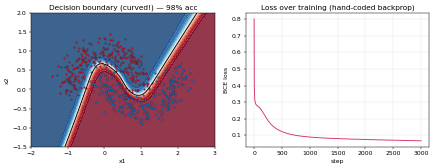

(also saved -> /content/plots/mlp_boundary.png)


In [9]:
# Decision boundary: ask the trained net its opinion on every point in the plane                    # +-- ASK THE NET ABOUT EVERY POINT IN THE PLANE -----------------
gx, gy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))                            # | The trained weights are evaluated on a 300x300 grid covering
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)                             # | the whole region, not just at the training points, which is
with torch.no_grad():                                                                               # | what makes the learned rule visible rather than just its
    prob = sigmoid(torch.tanh(grid @ W1 + b1) @ W2 + b2).numpy().reshape(gx.shape)                  # | score. no_grad stops the graph being recorded for a pass whose
                                                                                                    # | gradients are never used. The 0.5 contour is the boundary
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.0))                                             # | itself: the inputs the net is exactly undecided about. It is
                                                                                                    # | curved because tanh bends the space before the output neuron
axL.contourf(gx, gy, prob, levels=20, cmap="RdBu_r", alpha=0.8)                                     # | cuts it.
axL.contour(gx, gy, prob, levels=[0.5], colors="k", linewidths=1.5)   # the boundary
axL.scatter(Xnp[ynp==0,0], Xnp[ynp==0,1], s=8, color="#b2182b", edgecolor="k", lw=0.2)
axL.scatter(Xnp[ynp==1,0], Xnp[ynp==1,1], s=8, color="#2166ac", edgecolor="k", lw=0.2)
axL.set_title("Decision boundary (curved!) — 98% acc")
axL.set_xlabel("x1"); axL.set_ylabel("x2")

axR.plot(loss_hist, color="#d6336c")
axR.set_title("Loss over training (hand-coded backprop)")
axR.set_xlabel("step"); axR.set_ylabel("BCE loss"); axR.grid(alpha=0.3)

plt.tight_layout()
show(fig, "mlp_boundary", dpi_inline=44)

## Step 3 — Unmask autograd

`loss.backward()` is not magic — it's the *exact* chain rule you just wrote, applied automatically. PyTorch records every operation in the forward pass onto a graph, then walks it backward multiplying local slopes. To prove it: same weights, same data — compute gradients **both ways** and check they're identical.

In [10]:
# Same fixed weights, two ways to get gradients: BY HAND vs autograd                                # +-- THE SAME GRADIENTS, TWICE ----------------------------------
torch.manual_seed(7)                                                                                # | Both routes start from identical weights, so any difference is
W1_ = torch.randn(2, H) * 0.5; b1_ = torch.zeros(1, H)                                              # | a difference in method and not in initialization. The first
W2_ = torch.randn(H, 1) * 0.5; b2_ = torch.zeros(1, 1)                                              # | half repeats the hand-written chain rule. The second clones
                                                                                                    # | the same tensors, marks them as things to differentiate, runs
# ---- (A) BY HAND (our formulas from Step 2) ----                                                  # | only the forward pass and calls backward. requires_grad makes
z1 = X @ W1_ + b1_;  a1 = torch.tanh(z1)                                                            # | every operation record what produced it; backward walks that
z2 = a1 @ W2_ + b2_; p = sigmoid(z2)                                                                # | recording in reverse applying each operation's local
dz2 = (p - y) / X.shape[0]                                                                          # | derivative, which is the same arithmetic spelled out above.
dW2_hand = a1.t() @ dz2                                                                             # | The residual is at the level of float32 rounding, and that is
dz1 = (dz2 @ W2_.t()) * (1 - a1**2)                                                                 # | the whole point: autograd is bookkeeping, not a different
dW1_hand = X.t() @ dz1                                                                              # | rule.

# ---- (B) AUTOGRAD: just declare requires_grad and call backward() ----
W1a = W1_.clone().requires_grad_(); b1a = b1_.clone().requires_grad_()
W2a = W2_.clone().requires_grad_(); b2a = b2_.clone().requires_grad_()
pa   = sigmoid(torch.tanh(X @ W1a + b1a) @ W2a + b2a)
eps  = 1e-7
loss = -(y*torch.log(pa+eps) + (1-y)*torch.log(1-pa+eps)).mean()
loss.backward()                       # autograd walks the graph backward

# ---- compare ----
print("max |dW1_hand - dW1_autograd| =", (dW1_hand - W1a.grad).abs().max().item())
print("max |dW2_hand - dW2_autograd| =", (dW2_hand - W2a.grad).abs().max().item())
print("\nIdentical to ~1e-8. 'autograd' = the chain rule you wrote, done for you.")

max |dW1_hand - dW1_autograd| = 1.7881393432617188e-07
max |dW2_hand - dW2_autograd| = 1.4901161193847656e-07

Identical to ~1e-8. 'autograd' = the chain rule you wrote, done for you.


# Phase A — Why deep nets break: vanishing/exploding signals

Stack 20 layers. At each layer the activation gets multiplied by $W$ and squashed. Two failure modes:

- **Signal too small at init** → each layer shrinks it → after 20 layers the activations (and the gradients flowing back) are ~0. Early layers get **no gradient** → they never learn. This is the **vanishing gradient**, the reason nobody could train deep nets before ~2010.
- **Signal too big** → it explodes to infinity/NaN.

The fix is **initialization**: scale the random weights so the signal's *size stays roughly constant* layer-to-layer. The right scale depends on the activation:
- **Xavier/Glorot** (gain≈1, $\div\sqrt{\text{fan\_in}}$) for tanh
- **Kaiming/He** (gain=$\sqrt2$) for ReLU — corrects for ReLU zeroing half the signal

Below: one forward + one backward through a 20-layer net, three setups. We plot the **activation size** and **gradient size** at each layer. Watch the bad one nosedive.

In [11]:
# Push a signal through 20 layers and measure how big it stays, at init.                            # +-- HOW BIG IS THE SIGNAL AFTER 20 LAYERS ----------------------
def relu(z): return torch.clamp(z, min=0.0)                                                         # | A random input is pushed through 20 untrained layers and the
                                                                                                    # | spread of the activations is recorded at each one. The weight
def depth_experiment(act, gain, L=20, width=256, batch=512, seed=0):                                # | scale is gain over the square root of fan-in: each output is a
    torch.manual_seed(seed)                                                                         # | sum of `width` products, so its variance grows with width
    h = torch.randn(batch, width, device=device)     # input signal                                 # | unless the weights shrink by that square root. gain then
    Ws, act_std = [], []                                                                            # | corrects for what the nonlinearity removes - tanh compresses,
    for _ in range(L):                                                                              # | relu deletes half the signal, hence root two. Any loss will do
        # weight scale = gain / sqrt(fan_in)  <-- THE knob that controls everything                 # | at the end, because what is being measured is the size of the
        W = (torch.randn(width, width, device=device) * gain / width**0.5).requires_grad_()         # | gradient at each depth, not the loss value.
        Ws.append(W)
        h = act(h @ W)
        act_std.append(h.std().item())               # how big is the signal here?
    loss = h.pow(2).mean()                            # any loss; we just want gradients
    loss.backward()
    grad_std = [W.grad.std().item() for W in Ws]      # how big is the gradient here?
    return act_std, grad_std
                                                                                                    # +-- ONE NUMBER DECIDES WHETHER A DEEP NET CAN TRAIN ------------
configs = [                                                                                         # | The three settings differ only in that scale. At gain 0.5 the
    ("tanh, init x0.5  (too small)", torch.tanh, 0.5,        "#d6336c"),                            # | signal is multiplied by less than one at every layer, so after
    ("tanh, Xavier (gain 1)",        torch.tanh, 1.0,        "#2166ac"),                            # | 20 layers both the activations and the gradients have
    ("relu, Kaiming (gain root2)",   relu,       2**0.5,     "#2e7d32"),                            # | collapsed toward zero and no weight gets a usable update.
]                                                                                                   # | Xavier and Kaiming hold the spread roughly constant with
results = {name: depth_experiment(act, g) for name, act, g, _ in configs}                           # | depth, which is the condition being tested.

for name, _, _, _ in configs:
    a, gr = results[name]
    print(f"{name:32s} | act std L1->L20: {a[0]:.2e} -> {a[-1]:.2e} "
          f"| grad std: {gr[0]:.2e} -> {gr[-1]:.2e}")

tanh, init x0.5  (too small)     | act std L1->L20: 4.16e-01 -> 7.37e-07 | grad std: 2.73e-15 -> 2.31e-15
tanh, Xavier (gain 1)            | act std L1->L20: 6.28e-01 -> 1.58e-01 | grad std: 3.41e-05 -> 4.83e-05
relu, Kaiming (gain root2)       | act std L1->L20: 8.24e-01 -> 4.57e-01 | grad std: 6.64e-04 -> 1.96e-03


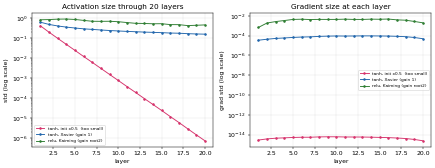

(also saved -> /content/plots/vanishing_gradients.png)


In [12]:
fig, (axA, axG) = plt.subplots(1, 2, figsize=(10, 4.0))                                             # +-- LOG AXIS, BECAUSE THE COLLAPSE IS EXPONENTIAL --------------
layers = range(1, 21)                                                                               # | The y axis is logarithmic because these quantities span many
for name, _, _, color in configs:                                                                   # | orders of magnitude; on a linear axis the collapsed run is a
    a, gr = results[name]                                                                           # | flat line at zero and shows nothing. A horizontal trace means
    axA.plot(layers, a, "-o", ms=3, color=color, label=name)                                        # | the signal keeps its size all the way down, which is the
    axG.plot(layers, gr, "-o", ms=3, color=color, label=name)                                       # | precondition for training deep at all.

axA.set_yscale("log"); axA.set_title("Activation size through 20 layers")
axA.set_xlabel("layer"); axA.set_ylabel("std (log scale)"); axA.legend(fontsize=7); axA.grid(alpha=0.3)
axG.set_yscale("log"); axG.set_title("Gradient size at each layer")
axG.set_xlabel("layer"); axG.set_ylabel("grad std (log scale)"); axG.legend(fontsize=7); axG.grid(alpha=0.3)
plt.tight_layout()
show(fig, "vanishing_gradients", dpi_inline=44)

In [13]:
# Train DEEP nets (8 layers) on the moons data: does init actually decide success?                  # +-- THE SAME INIT RULE, NOW IN A REAL TRAINING RUN -------------
Xg = X.to(device); yg = y.to(device)     # reuse moons data, on GPU                                 # | make_params builds a weight and bias pair per layer and marks
                                                                                                    # | them for gradients. forward applies each layer in turn and
def make_params(dims, gain, seed):                                                                  # | puts the nonlinearity on all but the last: the final layer has
    torch.manual_seed(seed)                                                                         # | to be free to produce any real number for sigmoid to map into
    P = []                                                                                          # | a probability, and squashing it first would throw that range
    for fin, fout in zip(dims[:-1], dims[1:]):                                                      # | away.
        W = (torch.randn(fin, fout, device=device) * gain / fin**0.5).requires_grad_()
        b = torch.zeros(1, fout, device=device, requires_grad=True)
        P.append((W, b))
    return P

def forward(P, x, act):
    h = x
    for i, (W, b) in enumerate(P):
        h = h @ W + b
        if i < len(P) - 1:        # nonlinearity on every layer except the last
            h = act(h)
    return sigmoid(h)

def train_deep(act, gain, depth=8, width=64, steps=2000, lr=0.3, seed=0):                           # +-- ZERO THE GRADS, STEP OUTSIDE THE GRAPH ---------------------
    dims = [2] + [width]*(depth-1) + [1]                                                            # | Gradients accumulate into .grad, so they are cleared before
    P = make_params(dims, gain, seed)                                                               # | each backward or the update would use the sum of every step
    hist = []                                                                                       # | taken so far. The update itself runs under no_grad because
    for _ in range(steps):                                                                          # | changing a weight is not an operation to differentiate;
        p = forward(P, Xg, act)                                                                     # | without it the graph would keep growing across steps and the
        loss = -(yg*torch.log(p+1e-7) + (1-yg)*torch.log(1-p+1e-7)).mean()                          # | memory with it. The three runs share depth, width, learning
        for W, b in P:                                                                              # | rate, seed and data, so the only thing that varies is the init
            if W.grad is not None: W.grad.zero_(); b.grad.zero_()                                   # | scale and the printed accuracy is the consequence of it.
        loss.backward()
        with torch.no_grad():
            for W, b in P:
                W -= lr*W.grad; b -= lr*b.grad
        hist.append(loss.item())
    acc = ((forward(P, Xg, act) > 0.5).float() == yg).float().mean().item()
    return hist, acc

runs = [
    ("8-layer tanh, init x0.5 (vanishing)", torch.tanh, 0.5,    "#d6336c"),
    ("8-layer tanh, Xavier",               torch.tanh, 1.0,    "#2166ac"),
    ("8-layer relu, Kaiming",              relu,       2**0.5, "#2e7d32"),
]
deep_hist = {}
for name, act, g, _ in runs:
    h, acc = train_deep(act, g)
    deep_hist[name] = h
    print(f"{name:38s} | final loss {h[-1]:.4f} | train acc {acc:.3f}")

8-layer tanh, init x0.5 (vanishing)    | final loss 0.0646 | train acc 0.978
8-layer tanh, Xavier                   | final loss 0.0384 | train acc 0.985
8-layer relu, Kaiming                  | final loss nan | train acc 0.500


16-layer tanh, init x0.5 (vanishing)     | final loss 0.6931 | train acc 0.800
16-layer tanh, Xavier                    | final loss 0.0421 | train acc 0.987
16-layer relu, Kaiming                   | final loss 0.0031 | train acc 0.998


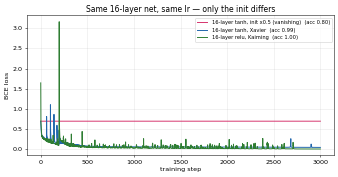

(also saved -> /content/plots/deep_init_training.png)


In [14]:
# Cleaner controlled experiment: 16 layers deep, SAME safe lr for all three.                        # +-- DOUBLE THE DEPTH, HOLD THE LEARNING RATE EQUAL -------------
runs16 = [                                                                                          # | Sixteen layers apply the scale factor twice as many times, so
    ("16-layer tanh, init x0.5 (vanishing)", torch.tanh, 0.5,    "#d6336c"),                        # | the collapse is that much worse. The learning rate is lowered
    ("16-layer tanh, Xavier",                torch.tanh, 1.0,    "#2166ac"),                        # | and made identical across all three runs, which removes the
    ("16-layer relu, Kaiming",               relu,       2**0.5, "#2e7d32"),                        # | objection that the failing run merely needed a different step
]                                                                                                   # | size. What is left is the init.
deep16 = {}
for name, act, g, _ in runs16:
    h, acc = train_deep(act, g, depth=16, width=64, steps=3000, lr=0.05)
    deep16[name] = (h, acc)
    print(f"{name:40s} | final loss {h[-1]:.4f} | train acc {acc:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.0))
for name, _, _, color in runs16:
    ax.plot(deep16[name][0], color=color, label=f"{name}  (acc {deep16[name][1]:.2f})")
ax.set_title("Same 16-layer net, same lr — only the init differs")
ax.set_xlabel("training step"); ax.set_ylabel("BCE loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
show(fig, "deep_init_training", dpi_inline=46)

# Phase B — A large net on real data, on the T4

Everything so far ran fine on a CPU — the nets were tiny. Now we go big enough that the GPU matters:

- **Real data**: FashionMNIST — 70k grayscale 28×28 images of clothing, 10 classes. Each image flattens to a **784-dim input** vector.
- **A real network**: a wide/deep MLP with **~1M+ parameters**, using everything from Phase A (Kaiming init, ReLU).
- **Mini-batches**: too much data to process at once — we feed it in chunks (the "batch" everyone talks about).
- **The T4**: we'll time fp32 vs **fp16** (half precision) and see the speedup the tensor cores give us.

In [15]:
# Load FashionMNIST and put the WHOLE dataset on the GPU as tensors (it's small enough).            # +-- PUT THE WHOLE DATASET ON THE GPU ---------------------------
import torchvision, time                                                                            # | FashionMNIST is 60000 28x28 grayscale images in ten clothing
from torchvision import transforms                                                                  # | classes. The whole set is small enough to sit in GPU memory as
                                                                                                    # | one tensor, which takes the host-to-device copy out of every
tf = transforms.Compose([transforms.ToTensor()])   # -> float in [0,1], shape (1,28,28)             # | batch and leaves the training loop limited by compute rather
train_ds = torchvision.datasets.FashionMNIST(root="/content/data", train=True,  download=True, transform=tf)
test_ds  = torchvision.datasets.FashionMNIST(root="/content/data", train=False, download=True, transform=tf)
                                                                                                    # | than by transfer. Each image is flattened to 784 numbers
# stack into big tensors, flatten 28x28 -> 784, normalize, move to GPU                              # | because an MLP has no notion of which pixels are next to each
def to_gpu_tensors(ds):                                                                             # | other. The mean and standard deviation are computed on the
    X = ds.data.float().view(len(ds), -1) / 255.0          # (N, 784)                               # | training set alone and then applied to the test set: taking
    y = ds.targets.clone()                                  # (N,)                                  # | them over the test set would leak the very thing the model is
    return X.to(device), y.to(device)                                                               # | being scored on.

Xtr, ytr = to_gpu_tensors(train_ds)
Xte, yte = to_gpu_tensors(test_ds)
# normalize using train mean/std (standard practice)
mu, sd = Xtr.mean(), Xtr.std()
Xtr = (Xtr - mu) / sd
Xte = (Xte - mu) / sd

classes = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print("train:", tuple(Xtr.shape), "| test:", tuple(Xte.shape), "| device:", Xtr.device)
print("classes:", classes)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.11MB/s]


train: (60000, 784) | test: (10000, 784) | device: cuda:0
classes: ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


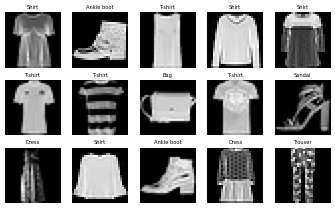

(also saved -> /content/plots/fashion_samples.png)


In [16]:
# Peek at 15 random images (un-normalize for display)                                               # +-- CHECK THE LABELS STILL MATCH THE PIXELS --------------------
torch.manual_seed(0)                                                                                # | The stored tensors are normalized, so multiplying by the
idx = torch.randint(0, len(Xtr), (15,))                                                             # | standard deviation and adding the mean back recovers something
imgs = (Xtr[idx]*sd + mu).cpu().view(-1, 28, 28).numpy()                                            # | that looks like the original image. Fifteen random samples
labs = ytr[idx].cpu().numpy()                                                                       # | with their class names is a check that all the reshaping did
                                                                                                    # | not shuffle labels away from images.
fig, axes = plt.subplots(3, 5, figsize=(7.5, 4.6))
for ax, im, lb in zip(axes.ravel(), imgs, labs):
    ax.imshow(im, cmap="gray"); ax.axis("off"); ax.set_title(classes[lb], fontsize=8)
plt.tight_layout()
show(fig, "fashion_samples", dpi_inline=46)

In [17]:
import torch.nn as nn                                                                               # +-- THE LIBRARY VERSION OF THE SAME LAYER ----------------------
                                                                                                    # | nn.Linear holds exactly the W and b written by hand in Step 2,
# A "large" MLP. Each nn.Linear is exactly our (W @ x + b) from Step 2.                             # | and Sequential simply calls each layer in order. The Kaiming
class BigMLP(nn.Module):                                                                            # | init from Phase A is applied explicitly rather than left to
    def __init__(self, sizes=(784, 1024, 512, 256, 10)):                                            # | the default, so that lesson carries into the library version.
        super().__init__()                                                                          # | The last layer has no relu after it: its ten outputs are raw
        layers = []                                                                                 # | scores, and the loss function applies softmax itself.
        for i in range(len(sizes) - 1):
            lin = nn.Linear(sizes[i], sizes[i+1])
            nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")  # Phase A fix!
            nn.init.zeros_(lin.bias)
            layers.append(lin)
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())     # nonlinearity on every layer but the last
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)                   # returns 10 raw scores (logits)

def n_params(m): return sum(p.numel() for p in m.parameters())

def train_model(model, epochs=15, bs=256, lr=1e-3, use_half=False):                                 # +-- ONE EPOCH, SHUFFLED, AND AN HONEST CLOCK -------------------
    model = model.to(device)                                                                        # | An epoch is one pass over the data in shuffled order, and the
    if use_half: model = model.half()                                                               # | permutation is redrawn each epoch so the same images are not
    opt = torch.optim.Adam(model.parameters(), lr=lr)                                               # | grouped into a batch every time. zero_grad clears the
    lossfn = nn.CrossEntropyLoss()           # = softmax + cross-entropy (multi-class BCE)          # | accumulation, backward fills .grad, step applies Adam's
    N = Xtr.shape[0]                                                                                # | update. The running loss is weighted by each batch's size so
    Xt = Xtr.half() if use_half else Xtr                                                            # | the final short batch does not count as much as a full one.
    tr_loss, te_acc = [], []                                                                        # | Test accuracy is measured under no_grad on all 10000 images at
    t0 = time.time()                                                                                # | once, which fits because the data already lives on the GPU.
    for ep in range(epochs):                                                                        # | CUDA calls are asynchronous, so synchronize before reading the
        perm = torch.randperm(N, device=device)        # shuffle each epoch                         # | clock forces the queued kernels to actually finish; without it
        running = 0.0                                                                               # | the timing measures how fast work was queued, not how fast it
        for i in range(0, N, bs):                                                                   # | ran.
            idx = perm[i:i+bs]
            xb, yb = Xt[idx], ytr[idx]
            opt.zero_grad()
            loss = lossfn(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(idx)
        tr_loss.append(running / N)
        with torch.no_grad():
            Xe = Xte.half() if use_half else Xte
            pred = model(Xe).argmax(1)
            te_acc.append((pred == yte).float().mean().item())
    torch.cuda.synchronize()
    return tr_loss, te_acc, time.time() - t0

model = BigMLP()
print(f"Network parameters: {n_params(model):,}")
print(model.net)

Network parameters: 1,462,538
Sequential(
  (0): Linear(in_features=784, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=10, bias=True)
)


trained 15 epochs in 7.3s on Tesla T4
final test accuracy: 0.8836


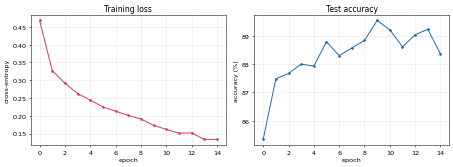

(also saved -> /content/plots/fashion_training.png)


In [18]:
# Train the 1.5M-param net (fp32) on the GPU                                                        # +-- THE FIRST SIGN OF OVERFITTING ------------------------------
torch.manual_seed(0)                                                                                # | The seed is set immediately before the model is built, so the
model = BigMLP()                                                                                    # | weights are reproducible. Training loss keeps falling while
tr_loss, te_acc, secs = train_model(model, epochs=15)                                               # | test accuracy flattens out - that divergence is the thing
print(f"trained 15 epochs in {secs:.1f}s on {torch.cuda.get_device_name(0)}")                       # | Phase E takes apart.
print(f"final test accuracy: {te_acc[-1]:.4f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.8))
axL.plot(tr_loss, "-o", ms=3, color="#d6336c"); axL.set_title("Training loss")
axL.set_xlabel("epoch"); axL.set_ylabel("cross-entropy"); axL.grid(alpha=0.3)
axR.plot([a*100 for a in te_acc], "-o", ms=3, color="#2166ac"); axR.set_title("Test accuracy")
axR.set_xlabel("epoch"); axR.set_ylabel("accuracy (%)"); axR.grid(alpha=0.3)
plt.tight_layout()
show(fig, "fashion_training", dpi_inline=46)

In [20]:
# fp32 vs mixed-precision (fp16 tensor cores) head-to-head                                          # +-- FP16 MATMULS WITH THE WEIGHTS STILL IN FP32 ----------------
def train_amp(model, epochs=15, bs=256, lr=1e-3, amp=False):                                        # | autocast runs the matrix multiplies in fp16, where the T4 has
    model = model.to(device)                                                                        # | dedicated tensor-core hardware, while the weights and the
    opt = torch.optim.Adam(model.parameters(), lr=lr)                                               # | reductions stay fp32 so accuracy is unaffected. fp16 has a far
    lossfn = nn.CrossEntropyLoss()                                                                  # | smaller exponent range, and gradients are small numbers: many
    scaler = torch.cuda.amp.GradScaler(enabled=amp)                                                 # | of them would round straight to zero. GradScaler multiplies
    N = Xtr.shape[0]                                                                                # | the loss by a large factor before backward so the gradients
    torch.cuda.synchronize(); t0 = time.time()                                                      # | land inside the representable range, divides that factor back
    for ep in range(epochs):                                                                        # | out before the optimizer steps, and drops the factor whenever
        perm = torch.randperm(N, device=device)                                                     # | the scaled values overflow.
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=amp):
                loss = lossfn(model(Xtr[idx]), ytr[idx])   # matmuls run in fp16 when amp=True
            scaler.scale(loss).backward()                  # scale loss -> avoid fp16 underflow
            scaler.step(opt); scaler.update()
    torch.cuda.synchronize()
    secs = time.time() - t0
    with torch.no_grad():
        acc = (model(Xte).argmax(1) == yte).float().mean().item()
    return secs, acc

# bigger net so the matmuls dominate and the tensor cores can shine                                 # +-- MAKE THE MATMULS BIG ENOUGH TO MEASURE ---------------------
big = (784, 2048, 2048, 1024, 10)                                                                   # | The speedup only appears when matrix multiplication dominates
torch.manual_seed(0); t32, a32 = train_amp(BigMLP(big), amp=False)                                  # | the runtime, so the layers are widened; on a small net the
torch.manual_seed(0); t16, a16 = train_amp(BigMLP(big), amp=True)                                   # | fixed per-kernel overhead hides it entirely. Same seed for
print(f"params: {n_params(BigMLP(big)):,}")                                                         # | both runs, so the two accuracies are comparable.
print(f"fp32  : {t32:5.1f}s   test acc {a32:.4f}")
print(f"fp16  : {t16:5.1f}s   test acc {a16:.4f}")
print(f"speedup: {t32/t16:.2f}x faster with mixed precision on the T4")

/tmp/ipykernel_101/1414881223.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp)


params: 7,912,458
fp32  :  18.5s   test acc 0.8882
fp16  :  14.1s   test acc 0.8888
speedup: 1.31x faster with mixed precision on the T4


# Phase C — Going genuinely deep: normalization + residuals

Phase A's init keeps the signal alive **at step 0**. But during training the weights move, and in a very deep net the activation scales drift again → optimization stalls. Two fixes:

**BatchNorm** — after each layer, re-center and re-scale the activations to mean 0 / std 1 *across the batch*, then let the net learn its own scale/shift. This keeps every layer's inputs well-conditioned at **every** step, not just at init.

**Residual connection** — instead of `h = F(h)`, compute `h = h + F(h)`. Now the gradient has a direct "+1" path back through every block, so it can't vanish. Each block only has to learn a small *correction* to the identity — much easier than re-learning everything.

We'll train a **50-layer** MLP three ways: init-only, +BatchNorm, +BatchNorm+residual. Watch the plain one struggle and the other two sail.

In [21]:
# A configurable VERY deep net: toggles for BatchNorm and residual connections                      # +-- FIFTY LAYERS, WITH TWO SWITCHES ----------------------------
class DeepNet(nn.Module):                                                                           # | BatchNorm normalizes each feature across the batch and then
    def __init__(self, depth=50, width=128, use_bn=False, use_res=False, in_dim=784, n_classes=10):
        super().__init__()                                                                          # | rescales it with learned parameters, which holds every layer's
        self.use_res, self.use_bn = use_res, use_bn                                                 # | input distribution steady while the weights below it move. Its
        self.inp  = nn.Linear(in_dim, width)                                                        # | own shift makes the linear layer's bias redundant, which is
        self.lins = nn.ModuleList([nn.Linear(width, width, bias=not use_bn) for _ in range(depth)])
        self.bns  = nn.ModuleList([nn.BatchNorm1d(width) if use_bn else nn.Identity() for _ in range(depth)])
        self.out  = nn.Linear(width, n_classes)                                                     # | what bias=not use_bn says. The residual line adds a block's
        for lin in [self.inp, *self.lins]:                      # Phase A: Kaiming init everywhere  # | input to its output, so the shortest route from the loss back
            nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")                                # | to an early layer passes through no weight matrix at all and
            if lin.bias is not None: nn.init.zeros_(lin.bias)                                       # | its gradient cannot be scaled away by depth.
    def forward(self, x):
        h = torch.relu(self.inp(x))
        for lin, bn in zip(self.lins, self.bns):
            z = torch.relu(bn(lin(h)))
            h = h + z if self.use_res else z                    # the shortcut
        return self.out(h)

def train_dn(model, epochs=10, bs=256, lr=1e-3):                                                    # +-- WHY train() AND eval() EXIST AT ALL ------------------------
    model = model.to(device)                                                                        # | The two modes matter here only because of BatchNorm: while
    opt = torch.optim.Adam(model.parameters(), lr=lr)                                               # | training it normalizes using the current batch's statistics
    lossfn = nn.CrossEntropyLoss(); N = Xtr.shape[0]                                                # | and updates a running average, and at evaluation it uses that
    tr_loss, te_acc = [], []                                                                        # | average instead, so a single test image is treated the same
    for ep in range(epochs):                                                                        # | way it would be inside a batch. Dropout later uses the same
        model.train()                                          # BN uses batch stats in train mode  # | switch.
        perm = torch.randperm(N, device=device); run = 0.0
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            loss = lossfn(model(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step(); run += loss.item()*len(idx)
        tr_loss.append(run/N)
        model.eval()                                           # BN uses running stats in eval mode
        with torch.no_grad():
            te_acc.append((model(Xte).argmax(1) == yte).float().mean().item())
    return tr_loss, te_acc

print("DeepNet ready. depth=50 ->", n_params(DeepNet(50,128)), "params (plain)")

DeepNet ready. depth=50 -> 927370 params (plain)


plain (Kaiming init only)      | final train loss 0.567 | test acc 0.8028
+ BatchNorm                    | final train loss 0.767 | test acc 0.7142
+ BatchNorm + residual         | final train loss 0.198 | test acc 0.8849


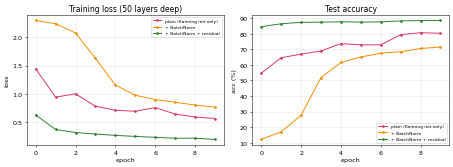

(also saved -> /content/plots/deep_norm_residual.png)


In [22]:
# Train a 50-layer net three ways. Same depth, width, init, lr, epochs.                             # +-- INIT ALONE IS NOT ENOUGH AT DEPTH 50 -----------------------
configs_c = [                                                                                       # | All three runs share depth, width, init, learning rate and
    ("plain (Kaiming init only)",   dict(use_bn=False, use_res=False), "#d6336c"),                  # | epochs, so the comparison isolates the two switches. The plain
    ("+ BatchNorm",                 dict(use_bn=True,  use_res=False), "#f08c00"),                  # | net trains badly despite correct Kaiming init, because init
    ("+ BatchNorm + residual",      dict(use_bn=True,  use_res=True),  "#2e7d32"),                  # | only fixes the signal size at step zero; once the weights
]                                                                                                   # | start moving, each layer's input distribution drifts out from
resC = {}                                                                                           # | under the layer above. BatchNorm restores that, and the
for name, kw, _ in configs_c:                                                                       # | shortcut restores the gradient path.
    torch.manual_seed(0)
    tl, ta = train_dn(DeepNet(depth=50, width=128, **kw), epochs=10)
    resC[name] = (tl, ta)
    print(f"{name:30s} | final train loss {tl[-1]:.3f} | test acc {ta[-1]:.4f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.8))
for name, _, c in configs_c:
    axL.plot(resC[name][0], "-o", ms=3, color=c, label=name)
    axR.plot([a*100 for a in resC[name][1]], "-o", ms=3, color=c, label=name)
axL.set_title("Training loss (50 layers deep)"); axL.set_xlabel("epoch"); axL.set_ylabel("loss")
axL.legend(fontsize=7); axL.grid(alpha=0.3)
axR.set_title("Test accuracy"); axR.set_xlabel("epoch"); axR.set_ylabel("acc (%)")
axR.legend(fontsize=7); axR.grid(alpha=0.3)
plt.tight_layout()
show(fig, "deep_norm_residual", dpi_inline=46)

# Phase D — Optimizers from scratch: SGD vs Momentum vs Adam

Gradient descent just steps against the gradient: `w -= lr * g`. But on a **ravine** — a loss surface that's steep in one direction and shallow in another — this is terrible: it bounces across the steep walls while crawling along the shallow floor. Two upgrades fix it:

- **Momentum**: accumulate a velocity, `v = µ·v − lr·g; w += v`. Like a heavy ball — it averages out the side-to-side bouncing and builds speed down the long shallow direction.
- **Adam**: keep a per-parameter running average of the gradient (`m`) *and* its square (`v`), then step `w -= lr·m/√v`. Dividing by √v **rescales every direction to the same size** — so steep and shallow directions get equal-sized steps. It basically reshapes the ravine into a round bowl.

We'll build all three by hand and trace their paths on an ill-conditioned bowl `L = ½(20·w₀² + w₁²)` (20× steeper in w₀ than w₁).

In [24]:
# A HARDER ill-conditioned bowl: 100x steeper in w0 than w1.                                        # +-- A RAVINE: 100x STEEPER ONE WAY THAN THE OTHER --------------
a, b = 100.0, 1.0                                                                                   # | The largest stable step size is set by the steepest direction,
def loss_fn(w): return 0.5 * (a*w[0]**2 + b*w[1]**2)                                                # | so plain gradient descent has to use a step small enough not
def grad_fn(w): return np.array([a*w[0], b*w[1]])     # dL/dw, by hand                              # | to bounce back and forth across the steep wall - and that same
                                                                                                    # | small step then crawls along the shallow floor. Momentum keeps
start = np.array([4.0, 4.0]); steps = 80                                                            # | a running velocity instead: the steep component keeps
                                                                                                    # | reversing sign and cancels itself out, while the shallow
def run_sgd(lr=0.018):                                                                              # | component always points the same way and accumulates, so the
    w = start.copy(); path = [w.copy()]                                                             # | effective step along the slow direction grows on its own.
    for _ in range(steps):
        w = w - lr*grad_fn(w)                          # plain step; lr capped by the STEEP wall
        path.append(w.copy())
    return np.array(path)

def run_momentum(lr=0.012, mu=0.9):
    w = start.copy(); v = np.zeros(2); path = [w.copy()]
    for _ in range(steps):
        v = mu*v - lr*grad_fn(w)                       # velocity builds along the shallow floor
        w = w + v
        path.append(w.copy())
    return np.array(path)

def run_adam(lr=0.3, b1=0.9, b2=0.999, eps=1e-8):                                                   # +-- ADAM: DIVIDE OUT EACH DIRECTION SCALE ----------------------
    w = start.copy(); m = np.zeros(2); v = np.zeros(2); path = [w.copy()]                           # | Adam keeps two running averages per parameter, one of the
    for t in range(1, steps+1):                                                                     # | gradient and one of its square, and divides the first by the
        g = grad_fn(w)                                                                              # | square root of the second. That division cancels the scale of
        m = b1*m + (1-b1)*g                            # running mean of gradient                   # | each direction, so a direction whose gradients are a hundred
        v = b2*v + (1-b2)*g*g                          # running mean of gradient^2                 # | times larger receives a hundred times smaller multiplier and
        mhat, vhat = m/(1-b1**t), v/(1-b2**t)          # bias correction                            # | both directions advance at a comparable rate. Both averages
        w = w - lr*mhat/(np.sqrt(vhat)+eps)            # rescale each direction equally             # | start at zero and are therefore biased toward zero early on,
        path.append(w.copy())                                                                       # | which is exactly what dividing by 1 - beta^t removes. eps only
    return np.array(path)                                                                           # | prevents a division by zero.

paths = {"SGD": (run_sgd(), "#d6336c"),
         "Momentum": (run_momentum(), "#f08c00"),
         "Adam": (run_adam(), "#2e7d32")}
for name, (p, _) in paths.items():
    print(f"{name:9s} | final loss {loss_fn(p[-1]):.4e} | reached |w|={np.linalg.norm(p[-1]):.4f}")

SGD       | final loss 4.3745e-01 | reached |w|=0.9354
Momentum  | final loss 7.5136e-03 | reached |w|=0.0248
Adam      | final loss 8.7468e-05 | reached |w|=0.0019


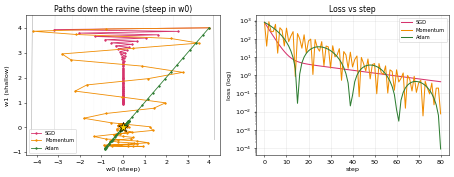

(also saved -> /content/plots/optimizers.png)


In [25]:
gw0, gw1 = np.meshgrid(np.linspace(-4.5, 4.5, 300), np.linspace(-0.5, 4.5, 300))                    # +-- SHAPE OF THE PATH, THEN SPEED OF DESCENT -------------------
Lsurf = 0.5*(a*gw0**2 + b*gw1**2)                                                                   # | The contour levels are spaced logarithmically because the loss
                                                                                                    # | spans four orders of magnitude across this region; evenly
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.0))                                             # | spaced levels would all crowd near the outer edge. The left
axL.contour(gw0, gw1, Lsurf, levels=np.logspace(-1, 3.2, 18), cmap="Greys", linewidths=0.6)         # | panel shows the route each method takes, the right shows how
for name, (p, c) in paths.items():                                                                  # | quickly it actually gets down.
    axL.plot(p[:,0], p[:,1], "-o", ms=2.5, lw=1.3, color=c, label=name)
axL.scatter([0],[0], marker="*", s=260, color="gold", edgecolor="k", zorder=5)
axL.set_title("Paths down the ravine (steep in w0)")
axL.set_xlabel("w0 (steep)"); axL.set_ylabel("w1 (shallow)"); axL.legend(fontsize=8)

for name, (p, c) in paths.items():
    axR.plot([loss_fn(w) for w in p], color=c, lw=1.6, label=name)
axR.set_yscale("log"); axR.set_title("Loss vs step")
axR.set_xlabel("step"); axR.set_ylabel("loss (log)"); axR.legend(fontsize=8); axR.grid(alpha=0.3)
plt.tight_layout()
show(fig, "optimizers", dpi_inline=46)

# Phase E — Overfitting and regularization, seen live

A big net has enough parameters to **memorize** the training set — getting 100% train accuracy by storing answers, not by learning a generalizable rule. The tell: train accuracy keeps rising while **test** accuracy (on data it never saw) stalls or drops. That gap = overfitting.

We force it by giving a big net only **1,000** images. Then two standard fixes:
- **Weight decay** — add a penalty on large weights to the loss, so the net prefers simple, smooth solutions over memorizing spikes.
- **Dropout** — randomly zero out half the neurons each step during training, so the net can't rely on memorizing specific neuron combinations; it must learn redundant, robust features.

Watch the train/test gap with and without them.

In [26]:
# Tiny training set + big net = a memorization machine. Then regularize it.                         # +-- MORE KNOBS THAN CONSTRAINTS --------------------------------
Xsmall, ysmall = Xtr[:1000], ytr[:1000]    # only 1000 images!                                      # | Roughly 670000 weights are handed 1000 images. There are far
                                                                                                    # | more free parameters than there are constraints, so the net
class RegMLP(nn.Module):                                                                            # | can fit the training set exactly while learning nothing that
    def __init__(self, p_drop=0.0):                                                                 # | transfers. Dropout zeroes a random half of each hidden layer's
        super().__init__()                                                                          # | outputs during training, so no single unit can be depended on
        self.fc1 = nn.Linear(784, 512); self.fc2 = nn.Linear(512, 512); self.fc3 = nn.Linear(512, 10)
        self.drop = nn.Dropout(p_drop)                                                              # | and the same input meets a different network each step; at
        for fc in [self.fc1, self.fc2]:                                                             # | evaluation it is switched off and everything passes through.
            nn.init.kaiming_normal_(fc.weight, nonlinearity="relu"); nn.init.zeros_(fc.bias)
    def forward(self, x):
        x = self.drop(torch.relu(self.fc1(x)))
        x = self.drop(torch.relu(self.fc2(x)))
        return self.fc3(x)

def train_reg(p_drop=0.0, wd=0.0, epochs=150, bs=128, lr=1e-3):                                     # +-- THE PENALTY THAT PREFERS SMALL WEIGHTS ---------------------
    torch.manual_seed(0)                                                                            # | weight_decay adds the size of the weights to the loss, so
    model = RegMLP(p_drop).to(device)                                                               # | every step also pulls each weight slightly toward zero and a
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)   # weight_decay = the penalty
    lossfn = nn.CrossEntropyLoss(); N = Xsmall.shape[0]                                             # | fit achieved with small weights is preferred over the same fit
    tr_acc, te_acc = [], []                                                                         # | with large ones. Train accuracy is measured on the same 1000
    for ep in range(epochs):                                                                        # | images the update used and test accuracy on 10000 unseen ones;
        model.train()                                                                               # | the gap between those two numbers is what overfitting actually
        perm = torch.randperm(N, device=device)                                                     # | is.
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            opt.zero_grad(); lossfn(model(Xsmall[idx]), ysmall[idx]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr_acc.append((model(Xsmall).argmax(1) == ysmall).float().mean().item())
            te_acc.append((model(Xte).argmax(1) == yte).float().mean().item())
    return tr_acc, te_acc

print("training (no regularization)...")
trA, teA = train_reg(p_drop=0.0, wd=0.0)
print("training (dropout 0.5 + weight decay)...")
trB, teB = train_reg(p_drop=0.5, wd=1e-3)
print(f"\nNo reg : train {trA[-1]:.3f}  test {teA[-1]:.3f}  -> gap {trA[-1]-teA[-1]:.3f}")
print(f"Reg    : train {trB[-1]:.3f}  test {teB[-1]:.3f}  -> gap {trB[-1]-teB[-1]:.3f}")

training (no regularization)...
training (dropout 0.5 + weight decay)...

No reg : train 1.000  test 0.806  -> gap 0.194
Reg    : train 1.000  test 0.801  -> gap 0.199


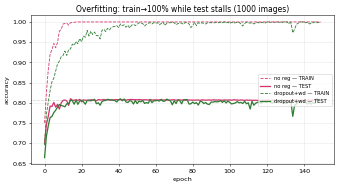

(also saved -> /content/plots/overfitting.png)


In [27]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))                                                          # +-- THE GAP, DRAWN ---------------------------------------------
ax.plot(trA, "--", color="#d6336c", lw=1.3, label="no reg — TRAIN")                                 # | Both runs are plotted together, dashed for train and solid for
ax.plot(teA, "-",  color="#d6336c", lw=2,   label="no reg — TEST")                                  # | test, so the vertical distance between a matched pair is the
ax.plot(trB, "--", color="#2e7d32", lw=1.3, label="dropout+wd — TRAIN")                             # | generalization gap. The unregularized train curve reaching
ax.plot(teB, "-",  color="#2e7d32", lw=2,   label="dropout+wd — TEST")                              # | 100% while its test curve stalls is the entire phenomenon in
ax.axhline(0.806, color="gray", ls=":", lw=0.8)                                                     # | one picture.
ax.set_title("Overfitting: train→100% while test stalls (1000 images)")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(fontsize=8, loc="center right")
ax.grid(alpha=0.3)
plt.tight_layout()
show(fig, "overfitting", dpi_inline=46)

corrupted 320 / 1000 training labels

No reg : memorized 100% of noisy labels -> CLEAN test 0.660
Reg    : memorized 100% of noisy labels -> CLEAN test 0.640
  regularization recovered +-2.0 points of test accuracy


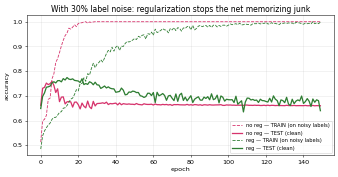

(also saved -> /content/plots/overfitting_noise.png)


In [28]:
# Corrupt 30% of the training labels. Now memorizing = memorizing WRONG answers.                    # +-- CORRUPT THE LABELS SO MEMORIZING IS VISIBLE ----------------
torch.manual_seed(1)                                                                                # | Thirty percent of the training labels are replaced with random
ynoisy = ysmall.clone()                                                                             # | classes. Fitting the training set now means memorizing answers
mask = torch.rand(1000, device=device) < 0.30                                                       # | that are known to be wrong, so training accuracy and useful
ynoisy[mask] = torch.randint(0, 10, (int(mask.sum()),), device=device)                              # | learning point in opposite directions and can finally be told
print(f"corrupted {int(mask.sum())} / 1000 training labels\n")                                      # | apart. Train accuracy is scored against the corrupted labels,
                                                                                                    # | because those are what the loss is minimizing, while test
def train_noisy(p_drop, wd, epochs=150, bs=128, lr=1e-3):                                           # | accuracy is scored against clean ones.
    torch.manual_seed(0)
    model = RegMLP(p_drop).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossfn = nn.CrossEntropyLoss(); N = 1000
    tr, te = [], []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(N, device=device)
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            opt.zero_grad(); lossfn(model(Xsmall[idx]), ynoisy[idx]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr.append((model(Xsmall).argmax(1) == ynoisy).float().mean().item())   # vs NOISY labels
            te.append((model(Xte).argmax(1) == yte).float().mean().item())         # vs CLEAN test
    return tr, te
                                                                                                    # +-- REGULARIZATION BUYS BACK REAL ACCURACY ---------------------
trN, teN = train_noisy(p_drop=0.0, wd=0.0)     # no regularization                                  # | The unregularized run drives its training accuracy up by
trR, teR = train_noisy(p_drop=0.5, wd=1e-3)    # dropout + weight decay                             # | absorbing the noise, and its clean test accuracy falls as it
print(f"No reg : memorized {trN[-1]:.0%} of noisy labels -> CLEAN test {teN[-1]:.3f}")              # | does. The regularized run cannot memorize as much and
print(f"Reg    : memorized {trR[-1]:.0%} of noisy labels -> CLEAN test {teR[-1]:.3f}")              # | therefore keeps more of the real signal.
print(f"  regularization recovered +{(teR[-1]-teN[-1])*100:.1f} points of test accuracy")

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(trN, "--", color="#d6336c", lw=1.3, label="no reg — TRAIN (on noisy labels)")
ax.plot(teN, "-",  color="#d6336c", lw=2,   label="no reg — TEST (clean)")
ax.plot(trR, "--", color="#2e7d32", lw=1.3, label="reg — TRAIN (on noisy labels)")
ax.plot(teR, "-",  color="#2e7d32", lw=2,   label="reg — TEST (clean)")
ax.set_title("With 30% label noise: regularization stops the net memorizing junk")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
show(fig, "overfitting_noise", dpi_inline=46)

no-reg on noisy data:
  peak test acc 0.758 at epoch 6
  final test acc 0.660 at epoch 149
  -> just STOPPING at the peak gives +9.8 points for free


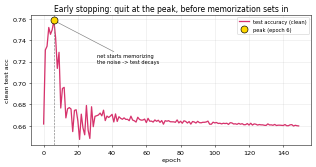

(also saved -> /content/plots/early_stopping.png)


In [29]:
# The real regularizer hiding in the noisy run: EARLY STOPPING.                                     # +-- THE REGULARIZER THAT COSTS NOTHING -------------------------
import numpy as np                                                                                  # | Test accuracy on the noisy run rises, peaks, then decays: the
teN_arr = np.array(teN)                                                                             # | real structure is learned before the noise is memorized.
peak_ep = int(teN_arr.argmax()); peak = teN_arr[peak_ep]; final = teN_arr[-1]                       # | Simply stopping at the peak recovers several points for free -
print(f"no-reg on noisy data:")                                                                     # | but locating the peak requires a held-out set, which is what a
print(f"  peak test acc {peak:.3f} at epoch {peak_ep}")                                             # | validation split is for.
print(f"  final test acc {final:.3f} at epoch {len(teN)-1}")
print(f"  -> just STOPPING at the peak gives +{(peak-final)*100:.1f} points for free")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(teN, color="#d6336c", lw=2, label="test accuracy (clean)")
ax.axvline(peak_ep, color="gray", ls="--", lw=1)
ax.scatter([peak_ep],[peak], color="gold", edgecolor="k", s=120, zorder=5, label=f"peak (epoch {peak_ep})")
ax.annotate("net starts memorizing\nthe noise -> test decays",
            xy=(peak_ep, peak), xytext=(peak_ep+25, peak-0.04),
            fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_title("Early stopping: quit at the peak, before memorization sets in")
ax.set_xlabel("epoch"); ax.set_ylabel("clean test acc"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
show(fig, "early_stopping", dpi_inline=46)

# Phase F — micrograd: write your own autograd

Autograd has two jobs:
1. **Forward**: compute the result, and *record* which operation produced each value and from which inputs (build a graph).
2. **Backward**: walk that graph in reverse, and at each node apply the **local derivative** times the gradient flowing in from above (the chain rule).

Our `Value` class wraps a single number. Every operation (`+`, `*`, `tanh`, ...) returns a new `Value` that remembers its parents and stores a tiny `_backward()` closure encoding that op's local derivative. Calling `.backward()` on the final value does a topological sort and runs every closure in reverse.

The local derivatives we need:
- `+` : gradient flows **unchanged** to both inputs ($\partial(a{+}b)/\partial a = 1$)
- `*` : each input gets the **other's value** ($\partial(ab)/\partial a = b$)
- `x**n` : $n\,x^{n-1}$
- `tanh` : $1-\tanh^2$
- `relu` : 1 if input > 0 else 0

That's the whole engine. Everything PyTorch does is this, vectorized onto tensors and a GPU.

In [32]:
import math                                                                                         # +-- AUTOGRAD, REBUILT FROM NOTHING -----------------------------
                                                                                                    # | Each Value carries its number, the slot its gradient will be
class Value:                                                                                        # | written into, a closure that knows how to push gradient back
    """A scalar that records the op-graph and can backprop itself."""                               # | to whatever produced it, and references to those producers.
    def __init__(self, data, _children=(), _op=''):                                                 # | Building the graph is a side effect of doing the arithmetic:
        self.data = data                                                                            # | every operation returns a new Value that remembers its inputs.
        self.grad = 0.0                 # dL/d(this), filled in by backward()                       # | Gradients accumulate with += rather than =, and that is what
        self._backward = lambda: None   # closure: how to push grad to parents                      # | makes a value used twice come out right - each use is a
        self._prev = set(_children)                                                                 # | separate path from the loss and the two contributions add.
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad      # d(a+b)/da = 1
            other.grad += out.grad      # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)                                 # +-- ONE RULE: LOCAL DERIVATIVE TIMES INCOMING GRAD -------------
        out = Value(self.data * other.data, (self, other), '*')                                     # | Each operation stores the derivative of its own output with
        def _backward():                                                                            # | respect to each input, multiplied by the gradient arriving
            self.grad  += other.data * out.grad   # d(ab)/da = b                                    # | from above. That product is the chain rule and it is the only
            other.grad += self.data  * out.grad   # d(ab)/db = a                                    # | rule in the file. For a product, the derivative with respect
        out._backward = _backward                                                                   # | to one factor is the other factor, so the closure captures
        return out                                                                                  # | both forward values. tanh reuses the number it already
                                                                                                    # | computed instead of recomputing it, because 1 - t^2 is
    def __pow__(self, n):               # n is a plain number                                       # | expressible in the output. relu passes gradient through where
        out = Value(self.data ** n, (self,), f'**{n}')                                              # | the input was positive and blocks it where it was not, which
        def _backward():                                                                            # | is why a unit whose input stays negative stops learning
            self.grad += (n * self.data**(n-1)) * out.grad                                          # | entirely.
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'relu')
        def _backward():
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    # niceties so we can write normal math (incl. reflected ops: float OP Value)                    # +-- ORDER THE GRAPH, THEN WALK IT BACKWARD ---------------------
    def __neg__(self):       return self * -1                                                       # | The reflected operators exist so a plain number can sit on the
    def __sub__(self, o):    return self + (-o)                                                     # | left of an operator: Python asks the right operand when the
    def __rsub__(self, o):   return (-self) + o          # o - self                                 # | left one does not know the type. Division is defined through a
    def __radd__(self, o):   return self + o                                                        # | power of minus one, so no new derivative is needed. backward
    def __rmul__(self, o):   return self * o                                                        # | first orders the graph so nothing is visited before everything
    def __truediv__(self, o):  return self * (o**-1 if isinstance(o, Value) else 1.0/o)             # | downstream of it: build appends a node only after recursing
    def __rtruediv__(self, o): return (self**-1) * o     # o / self                                 # | into its producers, which places producers earlier in the
    def __repr__(self):      return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"            # | list, so walking that list in reverse guarantees a node's
                                                                                                    # | gradient is complete before it is passed on. Seeding the last
    def backward(self):                                                                             # | gradient with 1 is the statement that the derivative of the
        # 1) topological order of the graph                                                         # | loss with respect to itself is one.
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        # 2) seed dL/dL = 1, then run closures in reverse
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

print("Value engine ready (with reflected ops)")

Value engine ready (with reflected ops)


In [34]:
# Same tangled expression in BOTH engines, compare gradients.                                       # +-- A DELIBERATELY TANGLED EXPRESSION --------------------------
# ---- (A) our hand-built engine ----                                                               # | Values are reused, added to themselves, and sent down two
a = Value(-4.0); b = Value(2.0)                                                                     # | branches that meet again at e. That is precisely the case a
c = a + b                                                                                           # | naive backward pass gets wrong, because gradient has to arrive
d = a * b + b**3                                                                                    # | along every path and be summed rather than overwritten.
c = c + c + 1
c = c + 1 + c + (-a)
d = d + d * 2 + (b + a).relu()
d = d + 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0 + 10.0 / f
g.backward()
print("OURS  : g =", round(g.data, 4), "| dg/da =", round(a.grad, 4), "| dg/db =", round(b.grad, 4))

# ---- (B) PyTorch on the identical expression (float64 for a fair comparison) ----                 # +-- CHECKED AGAINST PYTORCH AT FLOAT64 -------------------------
import torch as T                                                                                   # | The identical expression is rebuilt in PyTorch at float64, so
at = T.tensor(-4.0, requires_grad=True, dtype=T.float64); bt = T.tensor(2.0, requires_grad=True, dtype=T.float64)
ct = at + bt                                                                                        # | the comparison is not limited by float32 rounding. Agreement
dt = at * bt + bt**3                                                                                # | below 1e-9 says the hand-written engine implements the same
ct = ct + ct + 1                                                                                    # | derivative rules and the same accumulation over reused values.
ct = ct + 1 + ct + (-at)
dt = dt + dt * 2 + (bt + at).relu()
dt = dt + 3 * dt + (bt - at).relu()
et = ct - dt
ft = et**2
gt = ft / 2.0 + 10.0 / ft
gt.backward()
print("TORCH : g =", round(gt.item(), 4), "| dg/da =", round(at.grad.item(), 4), "| dg/db =", round(bt.grad.item(), 4))

print("\nmax grad difference:", max(abs(a.grad-at.grad.item()), abs(b.grad-bt.grad.item())))
print("match:", abs(a.grad-at.grad.item()) < 1e-9 and abs(b.grad-bt.grad.item()) < 1e-9)

OURS  : g = 24.7041 | dg/da = 138.8338 | dg/db = 645.5773
TORCH : g = 24.7041 | dg/da = 138.8338 | dg/db = 645.5773

max grad difference: 0.0
match: True


In [35]:
import random                                                                                       # +-- A NEURON BUILT OUT OF SCALARS ------------------------------
random.seed(1)                                                                                      # | A neuron holds one Value per input weight plus a bias, and its
                                                                                                    # | output is the sum of the products passed through tanh. The
# A neuron / layer / MLP, built ENTIRELY from Value objects (no torch, no numpy in the math)        # | initial scale is one over the square root of fan-in, the Phase
class Neuron:                                                                                       # | A rule applied one scalar at a time. sum is given the bias as
    def __init__(self, nin, nonlin=True):                                                           # | its starting value, so the bias enters the graph as an
        self.w = [Value(random.uniform(-1, 1) * nin**-0.5) for _ in range(nin)]                     # | ordinary addition rather than a special case. A layer is a
        self.b = Value(0.0)                                                                         # | list of neurons over the same input; it returns a bare Value
        self.nonlin = nonlin                                                                        # | instead of a one-element list so a single-output final layer
    def __call__(self, x):                                                                          # | reads as a scalar.
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)   # w·x + b
        return act.tanh() if self.nonlin else act
    def parameters(self): return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, **kw):
        self.neurons = [Neuron(nin, **kw) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    def parameters(self): return [p for n in self.neurons for p in n.parameters()]
                                                                                                    # +-- STACK THE LAYERS, FLATTEN THE PARAMETERS -------------------
class MLP:                                                                                          # | The nonlinearity is switched off on the last layer for the
    def __init__(self, sizes):                                                                      # | same reason as in the torch version: the output must be free
        self.layers = [Layer(sizes[i], sizes[i+1], nonlin=(i < len(sizes)-2))                       # | to take any value. parameters flattens the nested structure
                       for i in range(len(sizes)-1)]                                                # | into one flat list so the training loop can zero and step
    def __call__(self, x):                                                                          # | every scalar without knowing the shape of the network. Labels
        for layer in self.layers: x = layer(x)                                                      # | are mapped to -1 and +1 because the loss below is a squared
        return x                                                                                    # | error against the raw output, not a probability.
    def parameters(self): return [p for l in self.layers for p in l.parameters()]

# tiny moons dataset, labels in {-1, +1}
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100, noise=0.10, random_state=0)
ym = (ym * 2 - 1).tolist()
Xm = Xm.tolist()

net = MLP([2, 16, 16, 1])
print(f"net built from {len(net.parameters())} Value objects")

for step in range(101):                                                                             # +-- BUILD THE WHOLE GRAPH EVERY SINGLE STEP --------------------
    ypred = [net(x) for x in Xm]                                   # forward (builds graph)         # | Each step reconstructs the entire graph, one Value per scalar
    loss = sum((yp - yt)**2 for yp, yt in zip(ypred, ym)) * (1.0/len(ym))                           # | operation, then throws it away. The net is a few hundred
    for p in net.parameters(): p.grad = 0.0                        # zero grads                     # | numbers, which is the only reason that is affordable.
    loss.backward()                                               # YOUR autograd                   # | Gradients are zeroed by hand for the same reason as in torch:
    lr = 0.1                                                                                        # | backward adds into them.
    for p in net.parameters(): p.data -= lr * p.grad              # SGD step
    if step % 20 == 0:
        acc = sum((yp.data > 0) == (yt > 0) for yp, yt in zip(ypred, ym)) / len(ym)
        print(f"step {step:3d} | loss {loss.data:.4f} | accuracy {acc:.2%}")

net built from 337 Value objects
step   0 | loss 0.7875 | accuracy 81.00%
step  20 | loss 0.3550 | accuracy 86.00%
step  40 | loss 0.3439 | accuracy 89.00%
step  60 | loss 0.3391 | accuracy 89.00%
step  80 | loss 0.3337 | accuracy 89.00%
step 100 | loss 0.3269 | accuracy 89.00%


# Phase G — Convolutional networks

A `Conv2d` layer is a small grid of weights (a **filter**, e.g. 3×3) slid over the image. At each position it computes filter·patch + bias — exactly the `w·x+b` neuron you already know, just applied to a little local patch and **reused at every location**.

Two consequences:
- **Far fewer parameters**: one 3×3 filter = 9 weights, vs an MLP needing a separate weight per pixel per hidden unit.
- **Translation invariance**: a feature learned in one corner is detected everywhere, because it's the same filter sliding across.

A conv *layer* learns many filters (each a different feature detector). **Max-pooling** then shrinks the map (keeping the strongest response in each 2×2 window), giving a small amount of position-tolerance and reducing size. Stacking `conv → relu → pool` builds features from simple (edges) to complex (object parts). We'll train one and beat the MLP's ~88%.

In [36]:
# Reshape the (N,784) data back into images (N,1,28,28) for convolutions                            # +-- WEIGHT SHARING OVER A GRID ---------------------------------
Xtr_img = Xtr.view(-1, 1, 28, 28)                                                                   # | The flat 784-vectors are folded back into 28x28 images,
Xte_img = Xte.view(-1, 1, 28, 28)                                                                   # | because a convolution is defined over the grid. Conv2d slides
print("image tensors:", tuple(Xtr_img.shape), tuple(Xte_img.shape))                                 # | one small filter across the whole image and reuses the same
                                                                                                    # | weights at every position, so a pattern learned in one corner
class SmallCNN(nn.Module):                                                                          # | is recognized everywhere and the parameter count stops scaling
    def __init__(self):                                                                             # | with image size. padding=1 keeps the output the same size as
        super().__init__()                                                                          # | the input for a 3x3 filter. MaxPool halves each dimension, so
        self.features = nn.Sequential(                                                              # | the second layer's filters cover four times the area of the
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28->14                  # | original image that the first layer's do.
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def train_cnn(model, epochs=8, bs=256, lr=1e-3):                                                    # +-- FEWER PARAMETERS, BETTER ACCURACY --------------------------
    model = model.to(device)                                                                        # | This is the earlier loop with autocast always on, since
    opt = torch.optim.Adam(model.parameters(), lr=lr)                                               # | convolutions are exactly what the tensor cores accelerate;
    lossfn = nn.CrossEntropyLoss()                                                                  # | evaluation runs under autocast too, which is safe for a
    scaler = torch.amp.GradScaler('cuda')                                                           # | forward pass whose only use is an argmax. The CNN beats the
    N = Xtr_img.shape[0]; te_acc = []                                                               # | MLP with roughly a quarter of the parameters. The weight
    torch.cuda.synchronize(); t0 = time.time()                                                      # | sharing is a constraint that happens to be true of images, so
    for ep in range(epochs):                                                                        # | it removes capacity the model did not need in the first place.
        model.train()
        perm = torch.randperm(N, device=device)
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            with torch.autocast('cuda', dtype=torch.float16):
                loss = lossfn(model(Xtr_img[idx]), ytr[idx])
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        model.eval()
        with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
            te_acc.append((model(Xte_img).argmax(1) == yte).float().mean().item())
    torch.cuda.synchronize()
    return te_acc, time.time()-t0

cnn = SmallCNN()
print(f"CNN parameters: {n_params(cnn):,}  (vs MLP's 1,462,538)")
torch.manual_seed(0)
cnn = SmallCNN()
acc_cnn, secs = train_cnn(cnn, epochs=8)
print(f"trained 8 epochs in {secs:.1f}s")
print(f"CNN test accuracy: {acc_cnn[-1]:.4f}   (MLP baseline was ~0.884)")

image tensors: (60000, 1, 28, 28) (10000, 1, 28, 28)
CNN parameters: 421,642  (vs MLP's 1,462,538)
trained 8 epochs in 8.7s
CNN test accuracy: 0.9046   (MLP baseline was ~0.884)


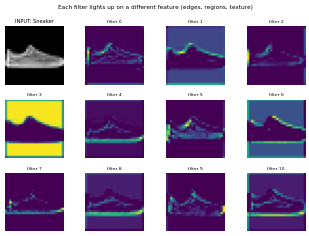

(also saved -> /content/plots/conv_feature_maps.png)


In [38]:
# Visualize what the first conv layer "sees": feature maps for one image                            # +-- WHAT THE FIRST LAYER ACTUALLY LEARNED ----------------------
cnn.eval()                                                                                          # | features[0] is the first convolution and features[1] the relu
k = 12                                                                                              # | after it, so applying them by hand gives the 32 activation
img = Xte_img[k:k+1]                                                                                # | maps for one image before any pooling. Each map is one
with torch.no_grad():                                                                               # | filter's response at every position, bright where the pattern
    a1 = cnn.features[1](cnn.features[0](img))    # conv1 -> relu, shape (1,32,28,28)               # | that filter matches is present. None of these filters were
maps = a1[0].cpu().numpy()                                                                          # | designed; they are whatever minimized the loss.

fig, axes = plt.subplots(3, 4, figsize=(7.2, 5.2))
# first panel: the input image (un-normalize on GPU, then move to CPU)
axes[0,0].imshow((img[0,0]*sd+mu).cpu().numpy(), cmap="gray")
axes[0,0].set_title(f"INPUT: {classes[yte[k].item()]}", fontsize=8); axes[0,0].axis("off")
# remaining panels: 11 different filters' responses
for ax, ch in zip(axes.ravel()[1:], range(11)):
    ax.imshow(maps[ch], cmap="viridis"); ax.axis("off")
    ax.set_title(f"filter {ch}", fontsize=7)
fig.suptitle("Each filter lights up on a different feature (edges, regions, texture)", fontsize=9)
plt.tight_layout()
show(fig, "conv_feature_maps", dpi_inline=46)

# Phase H — Data augmentation: make more data for free

In Phase E the net memorized 1,000 images because it had the capacity and the data was fixed. **Augmentation** breaks the memorization by showing a slightly different version of each image every epoch: random horizontal flips and small pixel shifts. The content (and label) is unchanged, but the exact pixels differ — so the net must learn *robust* features instead of memorizing exact pixel patterns.

This is the cheapest, most effective regularizer in computer vision, and it pairs perfectly with conv nets (whose translation-invariance the shifts directly exercise). We train the same `SmallCNN` on the same 1,000 images, with and without augmentation, and compare the train/test gap.

In [39]:
import torch.nn.functional as F                                                                     # +-- CHANGES THAT DO NOT CHANGE THE LABEL -----------------------
Xsmall_img = Xtr_img[:1000]           # same 1000 images as Phase E, as (N,1,28,28)                 # | Augmentation enlarges the training set by applying changes
# ysmall is already ytr[:1000] (clean labels)                                                       # | that leave the answer intact: a mirrored shirt is still a
                                                                                                    # | shirt, and a shirt moved three pixels is still a shirt. The
def augment(x):                                                                                     # | flip is decided per image; the shift is drawn once and applied
    """Random horizontal flip (per image) + small random shift (per batch). On GPU."""              # | to the whole batch, which is cheaper but correlates the images
    B = x.shape[0]                                                                                  # | inside a batch. Reflect padding is used so a crop never
    flip = (torch.rand(B, device=device) < 0.5)[:, None, None, None]                                # | introduces a black border the model could key on.
    x = torch.where(flip, torch.flip(x, dims=[3]), x)          # mirror left-right
    s = 3
    xp = F.pad(x, (s, s, s, s), mode="reflect")                # pad then random-crop = shift
    dx = torch.randint(0, 2*s+1, (1,)).item(); dy = torch.randint(0, 2*s+1, (1,)).item()
    return xp[:, :, dy:dy+28, dx:dx+28]

def train_aug(use_aug, epochs=60, bs=128, lr=1e-3):                                                 # +-- ONE LINE OF DIFFERENCE BETWEEN THE TWO RUNS ----------------
    torch.manual_seed(0)                                                                            # | Only the augment call separates them. Training accuracy is
    model = SmallCNN().to(device)                                                                   # | still measured on the unaugmented images so the number means
    opt = torch.optim.Adam(model.parameters(), lr=lr)                                               # | the same thing in both runs. Augmentation makes the training
    lossfn = nn.CrossEntropyLoss(); N = 1000                                                        # | problem harder, so on a fixed and short epoch budget it can
    tr_acc, te_acc = [], []                                                                         # | look worse - which is what the next cell corrects.
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(N, device=device)
        for i in range(0, N, bs):
            idx = perm[i:i+bs]
            xb = Xsmall_img[idx]
            if use_aug: xb = augment(xb)                       # <-- the only difference
            opt.zero_grad(); lossfn(model(xb), ysmall[idx]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr_acc.append((model(Xsmall_img).argmax(1) == ysmall).float().mean().item())
            te_acc.append((model(Xte_img).argmax(1) == yte).float().mean().item())
    return tr_acc, te_acc

print("training WITHOUT augmentation...");  trN, teN = train_aug(use_aug=False)
print("training WITH augmentation...");     trA, teA = train_aug(use_aug=True)
print(f"\nNo aug : train {trN[-1]:.3f}  test {teN[-1]:.3f}  -> gap {trN[-1]-teN[-1]:.3f}")
print(f"Aug    : train {trA[-1]:.3f}  test {teA[-1]:.3f}  -> gap {trA[-1]-teA[-1]:.3f}")
print(f"  augmentation changed test accuracy by {(teA[-1]-teN[-1])*100:+.1f} points")

training WITHOUT augmentation...
training WITH augmentation...

No aug : train 0.997  test 0.831  -> gap 0.166
Aug    : train 0.898  test 0.811  -> gap 0.087
  augmentation changed test accuracy by -2.1 points


no aug (150 epochs)...
aug    (150 epochs)...

No aug : train 1.000  test 0.838  (best test 0.841)  gap 0.162
Aug    : train 0.989  test 0.843  (best test 0.845)  gap 0.146
  best-test improvement from augmentation: +0.4 points


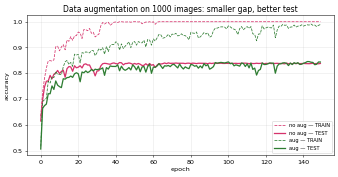

(also saved -> /content/plots/augmentation.png)


In [40]:
# Give augmentation enough epochs to converge (it trains slower), gentler shift.                    # +-- GIVE THE HARDER PROBLEM TIME TO CONVERGE -------------------
def augment(x, s=2):                                                                                # | With 150 epochs and a smaller maximum shift, the augmented run
    B = x.shape[0]                                                                                  # | has time to converge and the shift no longer discards so much
    flip = (torch.rand(B, device=device) < 0.5)[:, None, None, None]                                # | of a 28-pixel image. The train-test gap narrows and the best
    x = torch.where(flip, torch.flip(x, dims=[3]), x)                                               # | test accuracy improves, which is the actual claim: the same
    xp = F.pad(x, (s, s, s, s), mode="reflect")                                                     # | 1000 images, used more than one way, generalize further.
    dx = torch.randint(0, 2*s+1, (1,)).item(); dy = torch.randint(0, 2*s+1, (1,)).item()
    return xp[:, :, dy:dy+28, dx:dx+28]

print("no aug (150 epochs)..."); trN, teN = train_aug(use_aug=False, epochs=150)
print("aug    (150 epochs)..."); trA, teA = train_aug(use_aug=True,  epochs=150)
print(f"\nNo aug : train {trN[-1]:.3f}  test {teN[-1]:.3f}  (best test {max(teN):.3f})  gap {trN[-1]-teN[-1]:.3f}")
print(f"Aug    : train {trA[-1]:.3f}  test {teA[-1]:.3f}  (best test {max(teA):.3f})  gap {trA[-1]-teA[-1]:.3f}")
print(f"  best-test improvement from augmentation: {(max(teA)-max(teN))*100:+.1f} points")

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(trN, "--", color="#d6336c", lw=1.2, label="no aug — TRAIN")
ax.plot(teN, "-",  color="#d6336c", lw=2,   label="no aug — TEST")
ax.plot(trA, "--", color="#2e7d32", lw=1.2, label="aug — TRAIN")
ax.plot(teA, "-",  color="#2e7d32", lw=2,   label="aug — TEST")
ax.set_title("Data augmentation on 1000 images: smaller gap, better test")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
show(fig, "augmentation", dpi_inline=46)

In [ ]:
# Push this notebook to a NEW public GitHub repo (token stays in Colab Secrets, never printed)      # +-- THE TOKEN NEVER TOUCHES THE NOTEBOOK -----------------------
import json, base64, requests                                                                       # | The token is read from Colab Secrets rather than typed into a
from google.colab import userdata, _message                                                         # | cell, so it never reaches the saved file or its outputs, and
                                                                                                    # | scrub strips it out of any error text that does get printed.
OWNER   = "Maverick-Ansh"                                                                           # | get_ipynb asks the Colab frontend for the live notebook
REPO    = "neural-nets-from-scratch"                                                                # | including the outputs already rendered, which is why this cell
NB_NAME = "neural_nets_from_scratch.ipynb"                                                          # | has to run last. GitHub's contents API rejects a body over
                                                                                                    # | roughly one megabyte, so if the notebook plus its plots
try:                                                                                                # | exceeds that, the outputs are dropped and only the code is
    TOKEN = userdata.get('GITHUB_TOKEN')                                                            # | pushed.
except Exception as e:
    raise SystemExit("No GITHUB_TOKEN. In Colab: 🔑 sidebar -> add secret 'GITHUB_TOKEN' "
                     "(GitHub classic PAT, 'repo' scope) -> Notebook access ON -> re-run. "
                     f"({type(e).__name__})")

def scrub(s): return str(s).replace(TOKEN, '***')
H = {"Authorization": f"token {TOKEN}", "Accept": "application/vnd.github+json"}

# 1) grab the LIVE notebook (with outputs/plots)
nb = _message.blocking_request('get_ipynb', timeout_sec=120)['ipynb']
nb_json = json.dumps(nb, indent=1)
if len(nb_json.encode()) > 1_000_000:                 # keep under contents-API limit
    for c in nb.get('cells', []):
        if c.get('cell_type') == 'code':
            c['outputs'] = []; c['execution_count'] = None
    nb_json = json.dumps(nb, indent=1); stripped = True
else:
    stripped = False
print(f"notebook: {len(nb['cells'])} cells, {len(nb_json.encode())//1024} KB, "
      f"outputs {'stripped (too big)' if stripped else 'kept'}")
                                                                                                    # +-- MAKE THE PUSH RE-RUNNABLE ----------------------------------
# 2) create the repo                                                                                # | 422 from the repo-creation call means that name already exists
r = requests.post("https://api.github.com/user/repos", headers=H, json={                            # | on the account, which is treated as success so the cell can be
    "name": REPO, "private": False, "auto_init": False,                                             # | run again. The contents API needs the current blob sha to
    "description": "Neural nets from the ground up on a Colab T4: one neuron -> hand backprop -> "  # | replace a file and refuses without it, so put_file reads
                   "micrograd autograd -> deep nets (init/norm/residuals) -> optimizers -> conv nets -> augmentation."})
if r.status_code == 201:   print("repo created:", r.json()["html_url"])                             # | before it writes; a file that does not exist yet returns 404,
elif r.status_code == 422: print("repo exists, updating:", f"https://github.com/{OWNER}/{REPO}")    # | the sha is left out, and the PUT creates it.
else:                      raise SystemExit("repo create failed: " + scrub(r.text))

def put_file(path, text, msg):
    url = f"https://api.github.com/repos/{OWNER}/{REPO}/contents/{path}"
    body = {"message": msg, "content": base64.b64encode(text.encode()).decode(), "branch": "main"}
    g = requests.get(url, headers=H, params={"ref": "main"})
    if g.status_code == 200: body["sha"] = g.json()["sha"]
    p = requests.put(url, headers=H, json=body)
    if p.status_code not in (200, 201): raise SystemExit(f"push {path} failed: " + scrub(p.text))
    return p.json()["content"]["html_url"]

# 3) push notebook, then a README with an Open-in-Colab badge                                       # +-- BADGE POINTS AT GITHUB, NOT AT A COLAB FILE ----------------
put_file(NB_NAME, nb_json, "Add neural-nets-from-scratch notebook")                                 # | The README is written second so its badge can embed the link
colab_link = f"https://colab.research.google.com/github/{OWNER}/{REPO}/blob/main/{NB_NAME}"         # | to the notebook that was just pushed. That link resolves
readme = f"""# Neural Nets from Scratch

Built live on a Colab **T4 GPU**, from the ground up — no black boxes.

One neuron → hand-coded backprop → a from-scratch **autograd engine** (micrograd) → deep nets
(initialization, BatchNorm, residual connections) → optimizers (**SGD / Momentum / Adam** by hand) →
**convolutional nets** → **data augmentation**. Every gradient is understood and verified.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]({colab_link})

Click the badge to open and run. Then **Runtime → Change runtime type → T4 GPU**, and run the cells top to bottom.
"""
put_file("README.md", readme, "Add README with Open-in-Colab badge")                                # | through the GitHub path, so it always opens whatever is
                                                                                                    # | currently on main.
print("\n=== DONE ===")
print("Repo:          ", f"https://github.com/{OWNER}/{REPO}")
print("Open in Colab: ", colab_link)